#### **Задание 6**

Пусть известно решение $u(x), x\in [0, 1]$ начально-краевой задачи

$$ \dfrac{\partial u}{\partial t} - \Delta u = 0 , \quad x \in [0,1] , \quad t \in [0, 0.1]$$
$$ u(0,t) = 0 , \quad u(1,t) = 0 , \quad t \in [0,0.1]$$ 
с начальным условием

$$
u_0(x)=
\begin{cases} 
 \frac{x}{0.3}, & 0 \le x \le 0.3, \\
 \frac{1-x}{0.7}, & 0.3 < x \le 1,
\end{cases}
$$

Конечно разностная дискретизация

Неявная схема
$$
\dfrac{u^{n+1}_i - u^{n}_i}{\tau} - \dfrac{u^{n+1}_{i-1} - 2u^{n+1}_{i} + u^{n+1}_{i+1}}{h^2} = 0
$$

$$
-\left(\dfrac{1}{h^2}\right)u^{n+1}_{i-1} + \left(\dfrac{2}{h^2} + \dfrac{1}{\tau}\right)u^{n+1}_{i} -\left(\dfrac{1}{h^2}\right)u^{n+1}_{i+1}= \dfrac{u^{n}_{i}}{\tau} 
$$

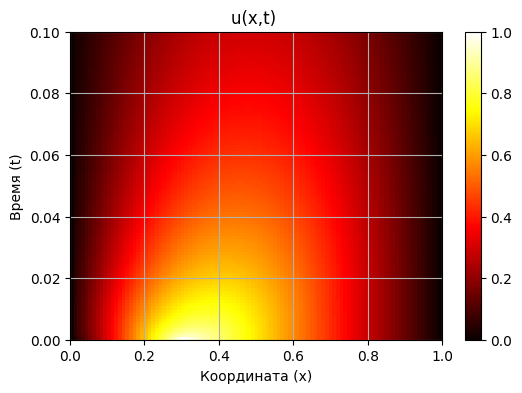

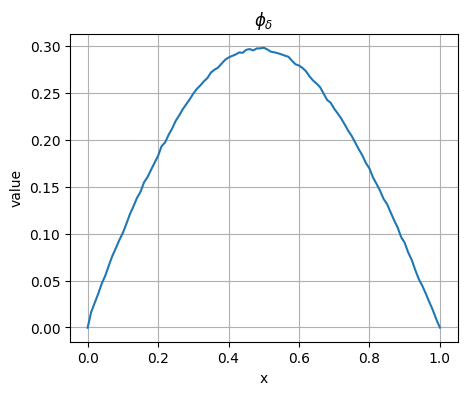

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def maps(value, titles):
    fig, ax1 = plt.subplots(figsize=(6, 4))
    im1 = ax1.imshow(value, extent=[ 0, Len, 0, T], aspect='auto', cmap='hot', origin='lower', interpolation='nearest')
    ax1.set_ylabel("Время (t)"); ax1.set_xlabel("Координата (x)"); ax1.set_title(f"{titles}(x,t) "); ax1.grid(True)
    fig.colorbar(im1, ax=ax1, orientation='vertical')
    plt.show()

def u_init(x):
    return x / 0.3 if ( x <= 0.3 and x > 0 ) else (1-x)/0.7

Len = 1.0
N = 100
T = 0.1
M = 100
h = Len / N
tau = T / M
x = np.linspace(0,Len,N+1)

A = -( 1 / h**2 )
B =  ( 2 / h**2 + 1 / tau)
C = -( 1 / h**2)

u = np.zeros((M+1,N+1))
u0 = [u_init(i*h) for i in range(N+1)]
u0[0] = 0
u0[N] = 0
u[0] = u0

for j in range(M):
    alpha = np.zeros((N+1))
    beta = np.zeros((N+1))
    alpha[0] = 0
    beta[0] = 0
    for i in range(N):
        alpha[i+1] = - C / (A * alpha[i] + B) 
        beta[i+1] = ( u[j,i]/tau - A * beta[i] ) / (A * alpha[i] + B)
    for i in range(N-1, 0, -1):
        u[j+1][i] = alpha[i+1]*u[j+1][i+1] + beta[i+1]

maps(u, "u")
delta = 0.001
sigma = np.random.normal(0,1,size=(N+1))
phi_delta = u[M] + delta * sigma
plt.figure(figsize=(5,4))
plt.plot(x, phi_delta)
plt.title(f"$\phi_\delta$"); plt.ylabel("value"); plt.xlabel("x"); plt.grid()
plt.show()


#### 
Восстановить функцию $ u_0(x) $ при заданном возмущенном решении $u(x, T) = \phi_\delta (x), x\in [0,1] $ , в финальным момент времени $ t = 0.1 $

* с помощью неявного итерационного метода

$$
B \dfrac{v_{k+1}-v_{k}}{s_{k+1}} + Av_k = \phi_\delta, \qquad B=E+\Lambda
$$


In [28]:
def L_create(n):
    A = np.zeros((n, n))  # Создаем пустую матрицу размера n x n
    for i in range(n):
        A[i, i] = -2
        if i > 0:
            A[i, i-1] = 1
        if i < n-1:
            A[i, i+1] = 1
    return A


L = - L_create(N+1) / h**2 
#print(L)
E = np.eye(N+1)
sigma = 1.0
S = np.linalg.inv(E + sigma * tau * L) @ (E + (sigma - 1) * tau * L)

A = S.copy()
for i in range(N):
    A = A @ S

#### с помощью итерационного метода минимальных поправок

0.02963308649890754
2


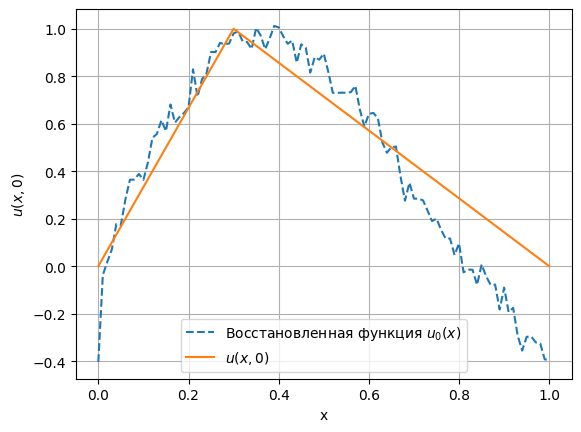

In [29]:
vk = np.zeros((N+1))
eps = np.sqrt(N)*delta
max_iter = 2000

B = (E + L)
B_inv = np.linalg.inv(B)

for i in range(max_iter):
    
    rk = A.dot(vk) - phi_delta

    wk =  rk

    s_k =  (A @ wk).dot(wk) / ( A @ wk).dot(A @ wk)
    
    vk_new = vk - s_k * wk 
    
    if (np.linalg.norm(rk) < 3*eps):
        print(np.linalg.norm(rk))
        print(i)
        break
    vk = vk_new

plt.plot(x, vk, '--', label="Восстановленная функция $u_0(x)$")
plt.plot(x, u0, label="$u(x,0)$")
plt.ylabel("$u(x,0)$"); plt.xlabel("x"); plt.grid(); plt.legend()
plt.show()

c помощью неявного метода простой итерации, при $s \approx 1$

0.000999710333357981


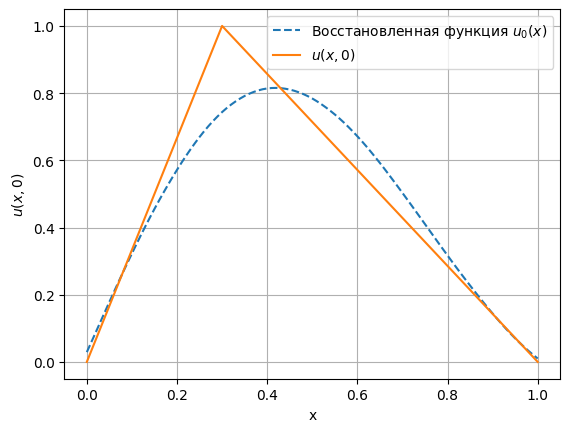

In [34]:
vk = np.zeros((N+1))
eps = np.sqrt(N)*delta
max_iter = 1000

s = 1.0
B = (E + s*L)
B_inv = np.linalg.inv(B)

for i in range(max_iter):
    
    #rk = A.dot(vk) - phi_delta
    
    vk_new = vk + s * B_inv @ (phi_delta - A @ vk) 
    
    if (np.linalg.norm(vk_new - vk) < 0.1 * eps):
        print(np.linalg.norm(vk_new - vk))
        break
    
    vk = vk_new

plt.plot(x, vk, '--', label="Восстановленная функция $u_0(x)$")
plt.plot(x, u0, label="$u(x,0)$")
plt.ylabel("$u(x,0)$"); plt.xlabel("x"); plt.grid(); plt.legend()
plt.show()